In [98]:
'''import kagglehub

path = kagglehub.dataset_download("juhibhojani/house-price")

print("Path to dataset files:", path)'''

'import kagglehub\n\npath = kagglehub.dataset_download("juhibhojani/house-price")\n\nprint("Path to dataset files:", path)'

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Load Dataset and General inspection of data 

In [100]:
df_org = pd.read_csv("D:\Python Programing\Python Practice\Demos\House price prediiction\Datasets\house_prices.csv")
df = df_org.copy()

In [101]:
df.shape

(187531, 21)

In [102]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [104]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:
missing_value = df.isna().sum().sort_values(ascending=False)
missing_pct = missing_value/len(df) *100 
pd.DataFrame({
    'Missing_count' : missing_value,
    'missing_pct' : missing_pct
})

,Missing_count,missing_pct
Plot Area,187531,100.000000
Dimensions,187531,100.000000
Society,109678,58.485264
Super Area,107685,57.422506
Car Parking,103357,55.114621
overlooking,81436,43.425354
Carpet Area,80673,43.018488
facing,70233,37.451408
Ownership,65517,34.936624
Balcony,48935,26.094352


<Axes: >

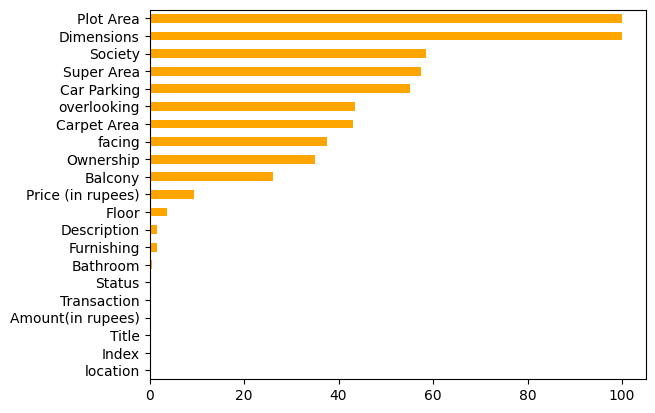

In [106]:
missing_pct.sort_values(ascending=True).plot(kind='barh' , color = 'orange')

In [107]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')

In [108]:
print("Full duplicate inspection: ",df.duplicated().sum())
print("Duplicate based own index column: ",df['Index'].duplicated().sum()) #act as primary key

Full duplicate inspection:  0
Duplicate based own index column:  0


## Handling missing values

In [109]:
# 100%  missing value
df.drop(columns=['Dimensions', 'Plot Area'],inplace=True)

In [110]:
# Society more than 60% missing and also not useful for prediction price
df.drop(columns=['Society'],inplace=True)

**Column:** `Carpet Area` , `Super Area` are duplicate of each other so fill missing based own super area because they contain value where other is missing.

In [111]:
# First clean both columns to pure numeric (remove 'sqft', commas, spaces)
df['Carpet Area'] = df['Carpet Area'].astype(str).str.replace('sqft', '', regex=False).str.replace(',', '').str.strip()
df['Super Area'] = df['Super Area'].astype(str).str.replace('sqft', '', regex=False).str.replace(',', '').str.strip()

df['Carpet Area'] = pd.to_numeric(df['Carpet Area'], errors='coerce')
df['Super Area'] = pd.to_numeric(df['Super Area'], errors='coerce')

# Fill Carpet Area with Super Area where Carpet is missing but Super exists
df['Sqrt_Area'] = df['Carpet Area'].fillna(df['Super Area'])

df.drop(columns=['Carpet Area','Super Area'],inplace=True)

In [112]:
# Less < 1% missing
df.dropna(subset=['Bathroom','Status','Transaction'],inplace = True)

### Filling data with missing Value between `1%` & `10%`

In [113]:
missing_pct = df.isnull().mean() * 100
under_10 = df.loc[:, (missing_pct < 11) & (missing_pct > 0)]
under_10.columns

Index(['Description', 'Price (in rupees)', 'Floor', 'Furnishing', 'Sqrt_Area'], dtype='object')

In [114]:
under_10.dtypes

Description           object
Price (in rupees)    float64
Floor                 object
Furnishing            object
Sqrt_Area            float64
dtype: object

In [115]:
print(under_10['Price (in rupees)'].skew())
print(under_10['Sqrt_Area'].skew())
# Data havily right skewed

176.4528155355603
205.48444264644348


In [116]:
# 1. Find the extreme values
print(df['Sqrt_Area'].sort_values(ascending=False).head(10))
print("Min ,Max")
print(df['Sqrt_Area'].min())
print(df['Sqrt_Area'].max())

165733    709222.0
149239    495970.0
147580    282004.0
50895     194936.0
147791    113134.0
82876     107806.0
180072     81845.0
176689     81675.0
176690     71775.0
176711     71025.0
Name: Sqrt_Area, dtype: float64
Min ,Max
1.0
709222.0


In [117]:
df['Sqrt_Area'].describe()
df['Sqrt_Area'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01     300.0
0.05     495.0
0.25     880.0
0.50    1180.0
0.75    1600.0
0.95    2500.0
0.99    3900.0
Name: Sqrt_Area, dtype: float64

In [118]:
lower_bound = df['Sqrt_Area'].quantile(0.01) 
upper_bound = df['Sqrt_Area'].quantile(0.99)   

# Count how many rows are outside this range
outliers = df[(df['Sqrt_Area'] < lower_bound) | (df['Sqrt_Area'] > upper_bound)]
print(f"Number of outlier rows: {len(outliers)}")

Number of outlier rows: 3411


In [119]:
df.loc[(df['Sqrt_Area'] < lower_bound) | (df['Sqrt_Area'] > upper_bound), 'Sqrt_Area'] = np.nan

In [120]:
df['Sqrt_Area'] = df['Sqrt_Area'].fillna(df['Sqrt_Area'].median())
print(df['Sqrt_Area'].skew())
print(df['Sqrt_Area'].describe())

1.3217329907262028
count    186009.000000
mean       1269.791768
std         555.970013
min         300.000000
25%         900.000000
50%        1180.000000
75%        1525.000000
max        3900.000000
Name: Sqrt_Area, dtype: float64


In [121]:
print(df['Sqrt_Area'].describe())
df['Sqrt_Area'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    186009.000000
mean       1269.791768
std         555.970013
min         300.000000
25%         900.000000
50%        1180.000000
75%        1525.000000
max        3900.000000
Name: Sqrt_Area, dtype: float64


0.01     400.0
0.05     500.0
0.25     900.0
0.50    1180.0
0.75    1525.0
0.95    2358.0
0.99    3350.0
Name: Sqrt_Area, dtype: float64

In [122]:
lower_bound = df['Price (in rupees)'].quantile(0.01) 
upper_bound = df['Price (in rupees)'].quantile(0.99)   

# Count how many rows are outside this range
outliers = df[(df['Price (in rupees)'] < lower_bound) | (df['Price (in rupees)'] > upper_bound)]
print(f"Number of outlier rows: {len(outliers)}")

Number of outlier rows: 2940


In [123]:
df.loc[(df['Price (in rupees)'] < lower_bound) | (df['Price (in rupees)'] > upper_bound), 'Price (in rupees)'] = np.nan

In [124]:
df['Price (in rupees)'] = df['Price (in rupees)'].fillna(df['Price (in rupees)'].median())
print(df['Price (in rupees)'].skew())
print(df['Price (in rupees)'].describe())

1.6606894630667872
count    186009.000000
mean       7085.801171
std        3748.622082
min        2228.000000
25%        4550.000000
50%        6034.000000
75%        8340.000000
max       23810.000000
Name: Price (in rupees), dtype: float64


In [125]:
under_10.dtypes

Description           object
Price (in rupees)    float64
Floor                 object
Furnishing            object
Sqrt_Area            float64
dtype: object

In [126]:
df['Furnishing'].value_counts(normalize=True) * 100

Furnishing
Semi-Furnished    47.810056
Unfurnished       41.266872
Furnished         10.923072
Name: proportion, dtype: float64

In [127]:
df['Furnishing'] = df['Furnishing'].fillna('Unknown')

In [128]:
df['Description'].value_counts(normalize = True)*100

Description
Multistorey apartment is available for sale. It is a good location property. Please contact for more details.                                                                                                                                                                                                                                                                                                                                                                                                                                                  1.492733
This gorgeous 3 BHK Flat is available for sale in Shiv Nagar, New Delhi. This flat for sale is a choice property. This ready to move flat in Shiv Nagar can be availed at a reasonable price of INR 1.35 Cr. The apartment's possession date is Jul '19. The flat is unfurnished and is suitable for any family size. The flat is in close proximity to prominent landmarks like shiv nagar..                                                       

In [129]:
df['Description'] = df['Description'].fillna('Unknown')

In [130]:
# Before fill value in Floor first extract data from data

# Split into current_floor and total_floors
df[['current_floor', 'total_floors']] = df['Floor'].str.extract(r'(\d+)\s*out of\s*(\d+)', expand=True)
df['current_floor'] = pd.to_numeric(df['current_floor'], errors='coerce')
df['total_floors'] = pd.to_numeric(df['total_floors'], errors='coerce')

# Now fill numeric columns with median (safe at 4-5% missing)
df['current_floor'] = df['current_floor'].fillna(df['current_floor'].median())
df['total_floors'] = df['total_floors'].fillna(df['total_floors'].median())

df.drop(columns=['Floor'],inplace=True)

# Handling missing data more that 20 percent


In [131]:
missing_pct = df.isnull().mean()*100
more_20 = df.loc[:,missing_pct>20]

In [132]:
more_20.dtypes

facing         object
overlooking    object
Balcony        object
Car Parking    object
Ownership      object
dtype: object

<Axes: xlabel='Balcony', ylabel='count'>

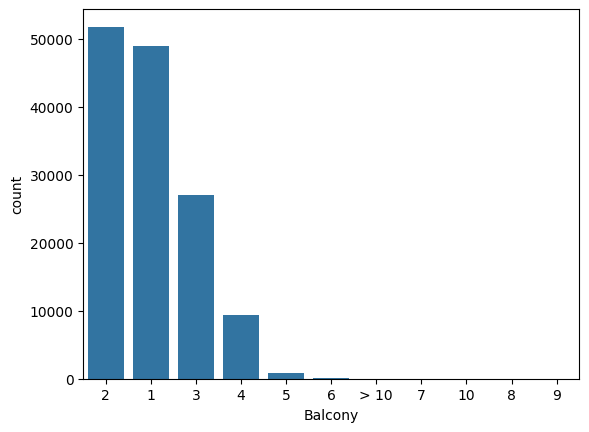

In [133]:
sns.barplot(df['Balcony'].value_counts())

In [134]:
df['Balcony'] = df['Balcony'].replace("> 10",'11')

In [135]:
df['Balcony'] = pd.to_numeric(df['Balcony'])

In [136]:
df['Balcony'].skew()

np.float64(0.9104725970787857)

In [137]:
print(df['Balcony'].mean())
print(df['Balcony'].median())

2.0032301051594774
2.0


In [138]:
df['Balcony'] = df['Balcony'].fillna(df['Balcony'].median())

In [139]:
df['facing'].value_counts(normalize=True)*100

facing
East            46.797287
North - East    20.719155
North           13.923238
West             7.263479
South            4.005960
North - West     3.286634
South - East     2.238474
South -West      1.765774
Name: proportion, dtype: float64

In [140]:
df['facing'] = df['facing'].fillna('Unknown')

In [141]:
more_20.columns

Index(['facing', 'overlooking', 'Balcony', 'Car Parking', 'Ownership'], dtype='object')

In [142]:
print(f"Overlooking: {df['overlooking'].value_counts(normalize=True)*100}\n\n\nCarParking: {df['Car Parking'].value_counts(normalize=True)*100}\n\n\nOwnership: {df['Ownership'].value_counts(normalize=True)*100}")

Overlooking: overlooking
Main Road                                      30.167809
Garden/Park, Main Road                         25.769916
Garden/Park                                    21.799121
Garden/Park, Pool, Main Road                   11.748551
Pool, Garden/Park, Main Road                    3.423425
Garden/Park, Pool                               2.665821
Main Road, Garden/Park, Pool                    1.286981
Pool, Main Road                                 1.075798
Pool                                            0.953635
Main Road, Garden/Park                          0.629759
Pool, Garden/Park                               0.411947
Garden/Park, Main Road, Pool                    0.036933
Main Road, Pool                                 0.010417
Main Road, Pool, Garden/Park                    0.007576
Pool, Main Road, Garden/Park                    0.005682
Main Road, Not Available                        0.003788
Garden/Park, Pool, Main Road, Not Available     0.000947
Garden

In [143]:
df['overlooking'] = df['overlooking'].fillna('Unknown')
df['Car Parking'] = df['Car Parking'].fillna('Unknown')
df['Ownership'] = df['Ownership'].fillna(df['Ownership'].mode()[0])

In [144]:
df.dtypes

Index                  int64
Title                 object
Description           object
Amount(in rupees)     object
Price (in rupees)    float64
location              object
Status                object
Transaction           object
Furnishing            object
facing                object
overlooking           object
Bathroom              object
Balcony              float64
Car Parking           object
Ownership             object
Sqrt_Area            float64
current_floor        float64
total_floors         float64
dtype: object

In [145]:
df_obj = df.select_dtypes(include='object')

In [146]:
temp = df['Amount(in rupees)'].str.extract(r'(\d+\.?\d*)\s*(Lac|Cr)')
temp.columns = ['value', 'unit']
temp['value'] = pd.to_numeric(temp['value'], errors='coerce')

unit_multiplier = {
    'Lac': 100000,
    'Cr': 10000000
}

df['Amount_numeric'] = temp['value'] * temp['unit'].map(unit_multiplier)

# Check how many rows became NaN (should match your "Call for Price" count)
print(df['Amount_numeric'].isnull().sum())
print(df[df['Amount_numeric'].isnull()]['Amount(in rupees)'].value_counts())

9581
Amount(in rupees)
Call for Price    9581
Name: count, dtype: int64


In [147]:
df = df.dropna(subset=['Amount_numeric'])

In [148]:
df_obj.columns

Index(['Title', 'Description', 'Amount(in rupees)', 'location', 'Status',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Bathroom',
       'Car Parking', 'Ownership'],
      dtype='object')

In [149]:
df['location'].value_counts().head(10) # need frequency encoding 

location
new-delhi        24927
bangalore        23225
kolkata          21572
gurgaon          18831
ahmedabad        12593
hyderabad        10811
chennai           9878
jaipur            7839
greater-noida     4394
faridabad         3681
Name: count, dtype: int64

In [150]:
# BUGFIX: previous version only mapped 'Ready to Move' -> 1, leaving any
# other status (e.g. 'Under Construction') as a raw string -> mixed dtype
# column. Map all known categories explicitly instead.
df['Status'] = df['Status'].map({'Ready to Move': 1, 'Under Construction': 0})


In [151]:
df['Transaction'].unique() #need one hot 3 unique values done after train split

array(['Resale', 'New Property', 'Other'], dtype=object)

In [152]:
df['Furnishing'].nunique() #need one hot 3 unique values done after train split

4

In [153]:
df['facing'].unique() #need one hot 3 unique values done after train split

array(['Unknown', 'East', 'West', 'North - East', 'North', 'North - West',
       'South', 'South -West', 'South - East'], dtype=object)

In [154]:
df['overlooking'].unique() 

array(['Unknown', 'Garden/Park', 'Garden/Park, Main Road', 'Main Road',
       'Pool, Garden/Park, Main Road', 'Garden/Park, Pool, Main Road',
       'Garden/Park, Pool', 'Main Road, Garden/Park',
       'Main Road, Garden/Park, Pool', 'Pool, Garden/Park', 'Pool',
       'Garden/Park, Main Road, Pool', 'Pool, Main Road',
       'Main Road, Pool, Garden/Park', 'Pool, Main Road, Garden/Park',
       'Main Road, Not Available', 'Main Road, Pool',
       'Garden/Park, Not Available', 'Pool, Main Road, Not Available'],
      dtype=object)

<Axes: ylabel='overlooking'>

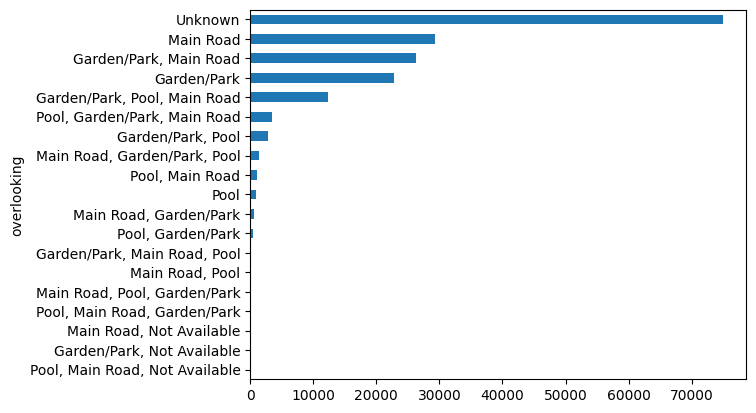

In [155]:
df['overlooking'].value_counts(ascending=True).plot(kind = 'barh')

In [156]:
df['overlooking'] = df['overlooking'].replace('Not Available', 'Unknown')
df['overlooking'] = df['overlooking'].str.replace(', Not Available', '', regex=False)
df['overlooking'] = df['overlooking'].str.replace('Not Available, ', '', regex=False)

In [157]:
def normalize_overlooking(val):
    if val == 'Unknown' or pd.isna(val):
        return 'Unknown'
    items = [x.strip() for x in val.split(',')]
    items = sorted(set(items))  # sorted + deduplicated
    return ', '.join(items)

df['overlooking'] = df['overlooking'].apply(normalize_overlooking)

In [158]:
df['overlooking'].unique()

array(['Unknown', 'Garden/Park', 'Garden/Park, Main Road', 'Main Road',
       'Garden/Park, Main Road, Pool', 'Garden/Park, Pool', 'Pool',
       'Main Road, Pool'], dtype=object)

In [159]:
df['overlook_garden'] = df['overlooking'].str.contains('Garden/Park').astype(int)
df['overlook_mainroad'] = df['overlooking'].str.contains('Main Road').astype(int)
df['overlook_pool'] = df['overlooking'].str.contains('Pool').astype(int)

df = df.drop(columns=['overlooking'])

In [160]:
df['Bathroom'] = df['Bathroom'].replace('> 10',"11")

In [161]:
df['Bathroom'] = df['Bathroom'].astype(int)

In [162]:
df['Ownership'].unique() #need one hot 3 unique values done after train split

array(['Freehold', 'Co-operative Society', 'Power Of Attorney',
       'Leasehold'], dtype=object)

In [163]:
df['Car Parking'].nunique()

217

In [164]:
df['Car Parking'].unique()[:30]

array(['Unknown', '1 Open', '1 Covered', '2 Covered', '66 Covered',
       '701 Covered', '3 Covered', '1 Covered,', '35 Open', '323 Covered',
       '11 Covered', '103 Open', '203 Covered', '2 Open', '180 Covered',
       '14 Open', '50 Open', '15 Open', '5 Open', '4 Covered',
       '509 Covered,', '4 Open', '6 Covered', '101 Covered', '10 Covered',
       '4 Covered,', '6 Covered,', '3 Covered,', '123 Covered',
       '505 Covered'], dtype=object)

In [165]:
# Step 1: Remove trailing commas
df['Car Parking'] = df['Car Parking'].str.strip().str.rstrip(',')

# Step 2: Extract numeric count and type (Covered/Open)
extracted = df['Car Parking'].str.extract(r'(\d+)\s*(Covered|Open)')
df['parking_count'] = pd.to_numeric(extracted[0], errors='coerce')
df['parking_type'] = extracted[1]

# Step 3: Check the realistic range before capping
print(df['parking_count'].quantile([0.01, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

0.01     1.0
0.25     1.0
0.50     1.0
0.75     1.0
0.90     2.0
0.95     2.0
0.99    34.0
Name: parking_count, dtype: float64


In [166]:
upper_bound = df['parking_count'].quantile(0.99)
df.loc[df['parking_count'] > upper_bound, 'parking_count'] = np.nan

In [167]:
df['parking_count'] = df['parking_count'].fillna(df['parking_count'].median())

In [168]:
print(df['parking_type'].value_counts(normalize=True) * 100)

parking_type
Covered    86.226842
Open       13.773158
Name: proportion, dtype: float64


In [169]:
df['parking_type'] = df['parking_type'].fillna(df['parking_type'].mode()[0])

In [170]:
df.drop(columns=['Car Parking','Amount(in rupees)'],inplace=True)

In [171]:
df.drop(columns=['Title','Description'],inplace=True)  # not benifical in predicting price

## Resolving issue find in analysis

In [172]:
df['Amount_numeric'].skew()

np.float64(269.3342849387086)

In [173]:
df['Amount_numeric'].sort_values(ascending=False).head(30)

181234    1.400300e+10
176536    5.100400e+09
174894    3.967500e+09
175013    2.298000e+09
183303    8.000000e+08
51966     6.000000e+08
50321     5.500000e+08
52058     5.500000e+08
52387     5.200000e+08
51965     5.000000e+08
50848     4.800000e+08
52866     4.200000e+08
114493    4.200000e+08
2002      4.200000e+08
1968      4.000000e+08
114459    4.000000e+08
115852    4.000000e+08
114443    3.680000e+08
1952      3.680000e+08
1951      3.600000e+08
2314      3.600000e+08
1967      3.600000e+08
114803    3.600000e+08
114458    3.600000e+08
114442    3.600000e+08
50050     3.400000e+08
117280    3.200000e+08
114891    3.000000e+08
116702    3.000000e+08
116705    3.000000e+08
Name: Amount_numeric, dtype: float64

In [174]:
df['Amount_numeric'].describe()

count    1.764280e+05
mean     1.202505e+07
std      3.958860e+07
min      1.000000e+05
25%      4.900000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: Amount_numeric, dtype: float64

In [175]:
# check how many rows are above, say, 100M (way beyond 75th percentile of 14.5M)
(df['Amount_numeric'] > 100_000_000).sum()

np.int64(281)

In [176]:
# Cap them at a threshold (if you want to keep the rows for other features)
df['Amount_numeric'] = df['Amount_numeric'].clip(upper=100_000_000)

In [177]:
df['price_log'] = np.log1p(df['Amount_numeric'])

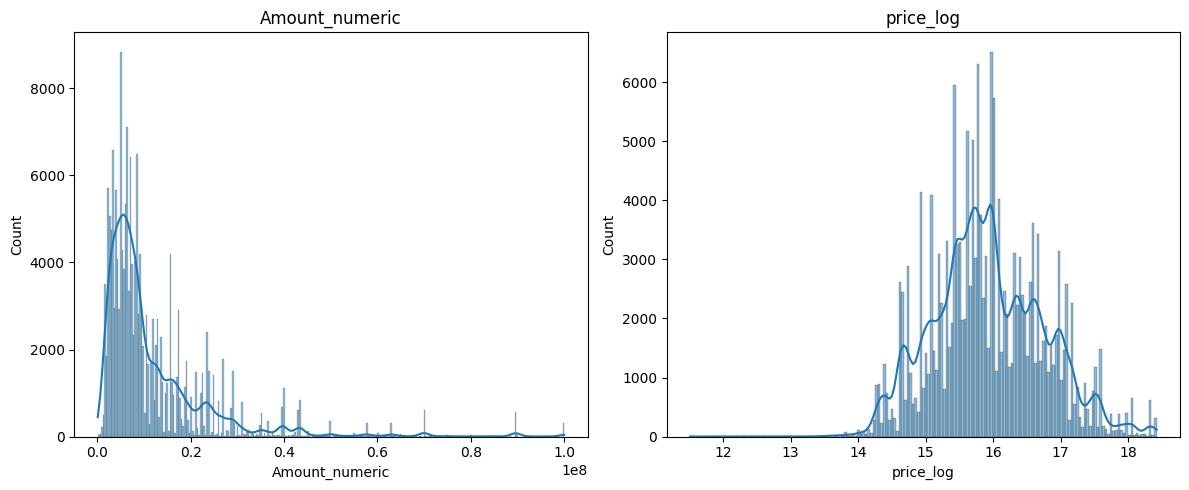

3.1992289055671908


In [178]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title("Amount_numeric")
sns.histplot(df['Amount_numeric'],kde=True,ax = ax[0])

plt.title("price_log")
sns.histplot(df['price_log'],kde=True, ax=ax[1])

plt.tight_layout()
plt.show()

print(df['Amount_numeric'].skew())

In [179]:
df['Amount_numeric'].skew()

np.float64(3.1992289055671908)

In [180]:
# sqrt_area skewed so apply logtransform
df['Sqrt_Area_transform'] = np.log1p(df['Sqrt_Area'])

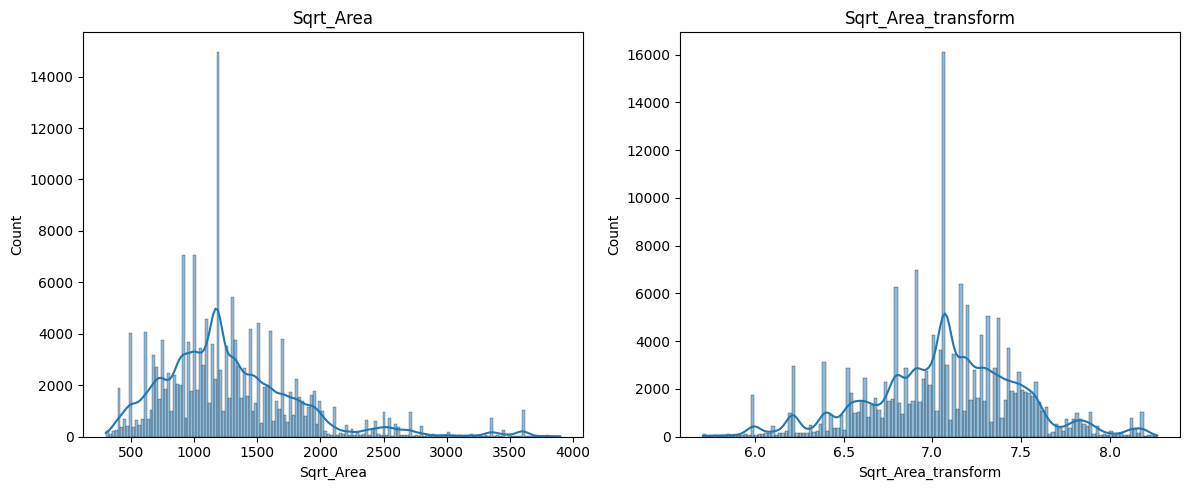

-0.16939949768817583


In [181]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title("Sqrt_Area")
sns.histplot(df['Sqrt_Area'], kde=True, ax=ax[0])

ax[1].set_title("Sqrt_Area_transform")
sns.histplot(df['Sqrt_Area_transform'], kde=True, ax=ax[1])

plt.tight_layout()
plt.show()

print(df['Sqrt_Area_transform'].skew())

In [182]:
df.drop(columns=['Index','Status','parking_count','parking_type'],inplace=True)

### Final outlier detection own all numeric column

In [183]:
def outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    return count

In [184]:
num_col = df.select_dtypes(include='number')

for col in num_col.columns:
    print(f"\nOutliers in {col}:")
    print(outliers(col))


Outliers in Price (in rupees):
8452

Outliers in Bathroom:
3560

Outliers in Balcony:
10257

Outliers in Sqrt_Area:
6611

Outliers in current_floor:
22297

Outliers in total_floors:
10448

Outliers in Amount_numeric:
12265

Outliers in overlook_garden:
0

Outliers in overlook_mainroad:
0

Outliers in overlook_pool:
22422

Outliers in price_log:
1318

Outliers in Sqrt_Area_transform:
2104


In [185]:
def iqr_bounds(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

# Price (in rupees) 
lower, upper = iqr_bounds('Price (in rupees)')
print("Price (in rupees) bounds:", lower, upper)
print(df[df['Price (in rupees)'] > upper]['Price (in rupees)'].sort_values(ascending=False).head(20))

Price (in rupees) bounds: -1759.0 14873.0
117031    23810.0
114502    23810.0
52492     23810.0
2011      23810.0
116039    23778.0
115565    23778.0
115681    23753.0
116712    23750.0
2402      23750.0
114890    23750.0
116495    23750.0
114279    23746.0
1787      23746.0
114841    23725.0
2352      23725.0
116109    23722.0
116038    23722.0
51829     23714.0
1842      23704.0
114333    23704.0
Name: Price (in rupees), dtype: float64


In [186]:
# Amount_numeric -- already handled earlier (removed >100M), just confirm
print(df['Amount_numeric'].describe())

count    1.764280e+05
mean     1.176269e+07
std      1.215168e+07
min      1.000000e+05
25%      4.900000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.000000e+08
Name: Amount_numeric, dtype: float64


In [187]:
# Sqrt_Area -- quick check for genuine extreme plots
lower, upper = iqr_bounds('Sqrt_Area')
print("Sqrt_Area bounds:", lower, upper)
print(df[df['Sqrt_Area'] > upper]['Sqrt_Area'].sort_values(ascending=False).head(20))

# price_log / Sqrt_Area_transform -- already log-transformed, leave as-is
# (residual "outliers" here are expected, not errors)

Sqrt_Area bounds: -75.0 2525.0
166473    3900.0
179747    3900.0
51482     3900.0
51151     3900.0
182004    3900.0
117990    3900.0
92356     3900.0
4448      3900.0
3553      3900.0
16745     3900.0
16746     3900.0
4446      3900.0
179302    3900.0
4447      3900.0
51136     3900.0
3797      3900.0
16936     3900.0
49979     3900.0
184682    3900.0
4720      3885.0
Name: Sqrt_Area, dtype: float64


In [188]:
for col in ['Bathroom', 'Balcony', 'current_floor', 'total_floors']:
    print(col, df[col].value_counts().sort_index())

Bathroom Bathroom
1     15470
2     88489
3     54106
4     14803
5      3277
6       185
7        32
8        14
9        11
10       12
11       29
Name: count, dtype: int64
Balcony Balcony
1.0     44818
2.0     96486
3.0     24867
4.0      9263
5.0       811
6.0       126
7.0        14
8.0        13
9.0         2
10.0       13
11.0       15
Name: count, dtype: int64
current_floor current_floor
1.0      30859
2.0      30730
3.0      41916
4.0      17182
5.0      11830
6.0       6848
7.0       6633
8.0       5188
9.0       2945
10.0      4976
11.0      3017
12.0      3792
13.0      1016
14.0      1603
15.0      1623
16.0      1171
17.0       979
18.0      1197
19.0       883
20.0       335
21.0       257
22.0       100
23.0       140
24.0        79
25.0        92
26.0        63
27.0        37
28.0        52
29.0        22
30.0        47
31.0        11
32.0       721
33.0        12
34.0        10
35.0        11
36.0         2
37.0         3
38.0         5
39.0         3
40.0        11


In [189]:
# ---------- Bathroom & Balcony: cap based on real drop-off point ----------
df['Bathroom'] = df['Bathroom'].clip(upper=5)
df['Balcony'] = df['Balcony'].clip(upper=5)

# ---------- current_floor & total_floors: cap extreme errors (200, 150, etc.) ----------
df['current_floor'] = df['current_floor'].clip(upper=df['current_floor'].quantile(0.99))
df['total_floors'] = df['total_floors'].clip(upper=df['total_floors'].quantile(0.99))

In [190]:
# ---------- Price (in rupees): DO NOT touch yet — investigate first ----------
# check relationship with Amount_numeric and Sqrt_Area before deciding
print(df[['Price (in rupees)', 'Amount_numeric', 'Sqrt_Area']].sample(20))

        Price (in rupees)  Amount_numeric  Sqrt_Area
80721              6004.0      10700000.0     1700.0
125534             5000.0       6000000.0      900.0
39074              5472.0       5800000.0     1060.0
144125             7231.0      23500000.0     3250.0
7563               5811.0       5230000.0      900.0
68958             16111.0      29000000.0     1500.0
182129             4700.0       4700000.0     1600.0
7034               5574.0       3000000.0     1180.0
111229             9646.0      12000000.0      740.0
100043             8636.0       9500000.0     1100.0
89499              4232.0       5100000.0     1190.0
48830              6825.0       4300000.0      580.0
112472             7737.0      12000000.0     1551.0
134162             4074.0       1650000.0     1180.0
16323              7625.0      13000000.0     1705.0
131504             5000.0       6000000.0      900.0
82030              4800.0       6000000.0     1250.0
88322              3799.0       5230000.0     

In [191]:
df.to_csv("D:\Python Programing\Python Practice\Demos\House price prediiction\Datasets\Ready for analysis.csv",index=False)

# Remaining
- `Columns1-5:` Ownership, Facing, Furnishing, Transaction (one-hot) and
  Location (frequency) are all encoded **inside the production notebook's
  `ColumnTransformer`**, not here.

**Design decision:** this notebook's job stops at cleaning. It does NOT
split into train/test and does NOT encode categoricals. Splitting is a
modeling decision, not a cleaning decision — it belongs in exactly one
place (`Production_ML_Pipeline.ipynb`), so there's no risk of two
notebooks disagreeing on the split or double-encoding a column. This
notebook just saves clean, raw (un-split, un-encoded) data.


In [192]:
# Save cleaned data. Categorical columns (location, Transaction, Furnishing,
# facing, Ownership) are left in their raw form on purpose -- encoding and
# train/test splitting both happen in Production_ML_Pipeline.ipynb, fit
# strictly on the training fold, so there's a single source of truth for
# both.
df.to_csv(
    r'D:\Python Programing\Python Practice\Demos\House price prediiction\Datasets\Ready for ML_production_Pipline.csv',
    index=False
)
